<a href="https://colab.research.google.com/github/olajidechris/CollabProjects/blob/main/G2_FIFA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# import pandas for data processing and cleaning
import pandas as pd

# import matplotlib.pyplot for graph plots
import matplotlib.pyplot as plt

# Set display all columns
pd.set_option('display.max_columns', None)

In [ ]:
# load the goalscorers csv and properly encode non english names
gs = pd.read_csv('/content/goalscorers.csv', encoding='utf-8-sig')
# check table head
gs.head()

,date,home_team,away_team,team,scorer,minute,own_goal,penalty
0,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,44.0,False,False
1,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,55.0,False,False
2,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,70.0,False,False
3,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,75.0,False,False
4,1916-07-06,Argentina,Chile,Argentina,Alberto Ohaco,2.0,False,False


In [ ]:
# check for duplicates
print(gs.duplicated().sum())

0


In [ ]:
# view duplicates
gs[gs.duplicated(keep=False)]

,date,home_team,away_team,team,scorer,minute,own_goal,penalty
4059,1963-11-26,Ghana,Ethiopia,Ghana,Edward Acquah,NaN,False,False
4060,1963-11-26,Ghana,Ethiopia,Ghana,Edward Acquah,NaN,False,False
4063,1963-11-28,Ethiopia,Tunisia,Ethiopia,Mengistu Worku,NaN,False,False
4064,1963-11-28,Ethiopia,Tunisia,Ethiopia,Mengistu Worku,NaN,False,False
4067,1963-11-28,Nigeria,Sudan,Sudan,Nasr Eddin Abbas,NaN,False,False
...,...,...,...,...,...,...,...,...
41297,2021-09-05,San Marino,Poland,Poland,Adam Buksa,90.0,False,False
41770,2021-10-12,Syria,Lebanon,Lebanon,Mohamad Kdouh,45.0,False,False
41771,2021-10-12,Syria,Lebanon,Lebanon,Mohamad Kdouh,45.0,False,False
42827,2022-09-25,Moldova,Liechtenstein,Moldova,Victor Stînă,90.0,False,False


In [ ]:
# remove duplicates
gs = gs.drop_duplicates()
print(gs.duplicated().sum())

0


In [ ]:
# check for null entries
gs.isnull().sum()

,0
date,0
home_team,0
away_team,0
team,0
scorer,11
minute,184
own_goal,0
penalty,0


In [ ]:
# Display rows with any null entries
display(gs[gs.isnull().any(axis=1)])

,date,home_team,away_team,team,scorer,minute,own_goal,penalty
3347,1960-10-16,Taiwan,Vietnam Republic,Taiwan,Yiu Cheuk Yin,NaN,False,False
4059,1963-11-26,Ghana,Ethiopia,Ghana,Edward Acquah,NaN,False,False
4063,1963-11-28,Ethiopia,Tunisia,Ethiopia,Mengistu Worku,NaN,False,False
4065,1963-11-28,Ethiopia,Tunisia,Ethiopia,Girma Tekle,NaN,False,False
4066,1963-11-28,Ethiopia,Tunisia,Ethiopia,Girma Tesfaye,NaN,False,False
...,...,...,...,...,...,...,...,...
16812,1997-03-27,Saudi Arabia,Bangladesh,Saudi Arabia,Abdullah Al-Dosari,NaN,False,False
16838,1997-03-29,Taiwan,Bangladesh,Taiwan,Hsu Te Ming,NaN,False,False
16839,1997-03-29,Taiwan,Bangladesh,Bangladesh,Alfaz Ahmed,NaN,False,False
16840,1997-03-29,Taiwan,Bangladesh,Bangladesh,Imtiaz Ahmed Nakib,NaN,False,False


In [ ]:
# remove rows with null entries
gs = gs.dropna(axis=0)

In [ ]:
# confirm that rows with null entries were removed
gs.isna().sum()

,0
date,0
home_team,0
away_team,0
team,0
scorer,0
minute,0
own_goal,0
penalty,0


In [ ]:
# check table columns and identify any null entries
gs.info()

<class 'pandas.core.frame.DataFrame'>
Index: 44181 entries, 0 to 44446
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   date       44181 non-null  object 
 1   home_team  44181 non-null  object 
 2   away_team  44181 non-null  object 
 3   team       44181 non-null  object 
 4   scorer     44181 non-null  object 
 5   minute     44181 non-null  float64
 6   own_goal   44181 non-null  bool   
 7   penalty    44181 non-null  bool   
dtypes: bool(2), float64(1), object(5)
memory usage: 2.4+ MB


In [ ]:
# change date column to datetime datatype
gs['date'] = pd.to_datetime(gs['date'])
# extract and create year column from date column
gs['year'] = gs['date'].dt.year


In [ ]:
# extract and create day_of_week column from date column
gs['day_of_week'] = gs['date'].dt.dayofweek + 1
# extract and create decade column from date column
gs['decade'] = (gs['date'].dt.year // 10) * 10

In [ ]:
# check table columns and identify any null entries
gs.info()

<class 'pandas.core.frame.DataFrame'>
Index: 44181 entries, 0 to 44446
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         44181 non-null  datetime64[ns]
 1   home_team    44181 non-null  object        
 2   away_team    44181 non-null  object        
 3   team         44181 non-null  object        
 4   scorer       44181 non-null  object        
 5   minute       44181 non-null  float64       
 6   own_goal     44181 non-null  bool          
 7   penalty      44181 non-null  bool          
 8   year         44181 non-null  int32         
 9   day_of_week  44181 non-null  int32         
 10  decade       44181 non-null  int32         
dtypes: bool(2), datetime64[ns](1), float64(1), int32(3), object(4)
memory usage: 2.9+ MB


In [ ]:
# check table head
gs.head(10)

,date,home_team,away_team,team,scorer,minute,own_goal,penalty,year,day_of_week,decade
0,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,44.0,False,False,1916,7,1910
1,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,55.0,False,False,1916,7,1910
2,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,70.0,False,False,1916,7,1910
3,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,75.0,False,False,1916,7,1910
4,1916-07-06,Argentina,Chile,Argentina,Alberto Ohaco,2.0,False,False,1916,4,1910
5,1916-07-06,Argentina,Chile,Chile,Telésforo Báez,44.0,False,False,1916,4,1910
6,1916-07-06,Argentina,Chile,Argentina,Juan Domingo Brown,60.0,False,True,1916,4,1910
7,1916-07-06,Argentina,Chile,Argentina,Juan Domingo Brown,62.0,False,True,1916,4,1910
8,1916-07-06,Argentina,Chile,Argentina,Alberto Marcovecchio,67.0,False,False,1916,4,1910
9,1916-07-06,Argentina,Chile,Argentina,Alberto Ohaco,75.0,False,False,1916,4,1910


In [ ]:
# Change scorer names to title case
gs['scorer'] = gs['scorer'].str.title()

In [ ]:
# Temporarily set display option to display all rows
pd.set_option('display.max_rows', None)

# Group 'scorer' column by count
display(gs['scorer'].value_counts())

# Reset display rows
pd.reset_option('display.max_rows')

,count
scorer,
Cristiano Ronaldo,108
Robert Lewandowski,62
Romelu Lukaku,60
Harry Kane,58
Lionel Messi,55
Edin Džeko,50
Ali Daei,49
Miroslav Klose,48
Aleksandar Mitrović,47


In [ ]:
# load the former_names csv and properly encode non english names
fn = pd.read_csv('/content/former_names.csv', encoding='utf-8-sig')

# check table head
fn.head(27)


,current,former,start_date,end_date
0,Benin,Dahomey,1959-11-08,1975-11-30
1,Burkina Faso,Upper Volta,1960-04-14,1984-08-04
2,Curaçao,Netherlands Antilles,1957-03-03,2010-10-10
3,Czechoslovakia,Bohemia,1903-04-05,1919-01-01
4,Czechoslovakia,Bohemia and Moravia,1939-01-01,1945-05-01
5,Czechoslovakia,Representation of Czechs and Slovaks,1993-03-24,1993-11-17
6,DR Congo,Belgian Congo,1948-05-25,1956-01-02
7,DR Congo,Congo-Léopoldville,1963-04-12,1964-07-19
8,DR Congo,Congo-Kinshasa,1965-01-09,1970-11-24
9,DR Congo,Zaïre,1971-01-10,1997-04-27


In [ ]:
# change start_date column to datetime datatype
fn['start_date'] = pd.to_datetime(fn['start_date'])
# change end_date column to datetime datatype
fn['end_date'] = pd.to_datetime(fn['end_date'])

In [ ]:
# check table columns and identify any null entries
fn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   current     34 non-null     object        
 1   former      34 non-null     object        
 2   start_date  34 non-null     datetime64[ns]
 3   end_date    34 non-null     datetime64[ns]
dtypes: datetime64[ns](2), object(2)
memory usage: 1.2+ KB


In [ ]:
# load the shootouts csv and properly encode non english names
shoot = pd.read_csv('/content/shootouts.csv', encoding='utf-8-sig')
# check table head
shoot.head(10)

,date,home_team,away_team,winner,first_shooter
0,1967-08-22,India,Taiwan,Taiwan,NaN
1,1971-11-14,South Korea,Vietnam Republic,South Korea,NaN
2,1972-05-07,South Korea,Iraq,Iraq,NaN
3,1972-05-17,Thailand,South Korea,South Korea,NaN
4,1972-05-19,Thailand,Cambodia,Thailand,NaN
5,1973-04-21,Senegal,Ghana,Ghana,NaN
6,1973-06-14,Guinea,Mali,Guinea,NaN
7,1973-06-14,Mauritius,Tanzania,Mauritius,NaN
8,1973-07-26,Malaysia,Kuwait,Malaysia,NaN
9,1973-07-26,Cambodia,Singapore,Singapore,NaN


In [ ]:
# check table tail
shoot.tail(20)

,date,home_team,away_team,winner,first_shooter
630,2024-03-23,Tunisia,Croatia,Croatia,Croatia
631,2024-03-26,New Zealand,Tunisia,Tunisia,New Zealand
632,2024-03-26,Wales,Poland,Poland,Poland
633,2024-03-26,Georgia,Greece,Georgia,Georgia
634,2024-03-26,Turks and Caicos Islands,Anguilla,Anguilla,Turks and Caicos Islands
635,2024-03-26,British Virgin Islands,United States Virgin Islands,British Virgin Islands,British Virgin Islands
636,2024-06-11,Lithuania,Estonia,Estonia,Lithuania
637,2024-07-01,Portugal,Slovenia,Portugal,Slovenia
638,2024-07-04,Argentina,Ecuador,Argentina,Argentina
639,2024-07-05,Portugal,France,France,France


In [ ]:
# Change null first_shooter entries to unknown
shoot['first_shooter'] = shoot['first_shooter'].fillna('Unknown')

In [ ]:
# check null entries were changed
shoot.head(15)

,date,home_team,away_team,winner,first_shooter
0,1967-08-22,India,Taiwan,Taiwan,Unknown
1,1971-11-14,South Korea,Vietnam Republic,South Korea,Unknown
2,1972-05-07,South Korea,Iraq,Iraq,Unknown
3,1972-05-17,Thailand,South Korea,South Korea,Unknown
4,1972-05-19,Thailand,Cambodia,Thailand,Unknown
5,1973-04-21,Senegal,Ghana,Ghana,Unknown
6,1973-06-14,Guinea,Mali,Guinea,Unknown
7,1973-06-14,Mauritius,Tanzania,Mauritius,Unknown
8,1973-07-26,Malaysia,Kuwait,Malaysia,Unknown
9,1973-07-26,Cambodia,Singapore,Singapore,Unknown


In [ ]:
# check table columns and identify any null entries
shoot.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 650 entries, 0 to 649
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   date           650 non-null    object
 1   home_team      650 non-null    object
 2   away_team      650 non-null    object
 3   winner         650 non-null    object
 4   first_shooter  650 non-null    object
dtypes: object(5)
memory usage: 25.5+ KB


In [ ]:
# Group 'first_shooter' column by count
shoot['first_shooter'].value_counts()

,count
first_shooter,
Unknown,415
Colombia,11
Italy,10
Brazil,9
Argentina,8
...,...
Turks and Caicos Islands,1
British Virgin Islands,1
Slovenia,1


In [ ]:
# extract and create winning_team column from away column
shoot['winning_team'] = shoot.apply(lambda row: 'home' if row['home_team'] == row['winner'] else 'away', axis=1)

In [ ]:
# check table head
shoot.head(5)

,date,home_team,away_team,winner,first_shooter,winning_team
0,1967-08-22,India,Taiwan,Taiwan,Unknown,away
1,1971-11-14,South Korea,Vietnam Republic,South Korea,Unknown,home
2,1972-05-07,South Korea,Iraq,Iraq,Unknown,away
3,1972-05-17,Thailand,South Korea,South Korea,Unknown,away
4,1972-05-19,Thailand,Cambodia,Thailand,Unknown,home


In [ ]:
# check table
shoot

,date,home_team,away_team,winner,first_shooter,winning_team
0,1967-08-22,India,Taiwan,Taiwan,Unknown,away
1,1971-11-14,South Korea,Vietnam Republic,South Korea,Unknown,home
2,1972-05-07,South Korea,Iraq,Iraq,Unknown,away
3,1972-05-17,Thailand,South Korea,South Korea,Unknown,away
4,1972-05-19,Thailand,Cambodia,Thailand,Unknown,home
...,...,...,...,...,...,...
645,2024-09-10,Cambodia,Sri Lanka,Sri Lanka,Cambodia,away
646,2025-06-08,Portugal,Spain,Portugal,Portugal,home
647,2025-06-28,Panama,Honduras,Honduras,Panama,away
648,2025-06-29,Canada,Guatemala,Guatemala,Canada,away


In [ ]:
# Group shoot by count of 'first_shooter' and 'winning_team'
shoot_grouped = shoot.groupby(['first_shooter', 'winning_team']).size().reset_index(name='count').sort_values(by='count', ascending=False)
# display groupby
display(shoot_grouped)

,first_shooter,winning_team,count
116,Unknown,home,229
115,Unknown,away,186
21,Colombia,away,7
8,Brazil,away,6
56,Italy,away,5
...,...,...,...
119,Uzbekistan,home,1
120,Venezuela,away,1
121,Vietnam,away,1
122,Zambia,away,1


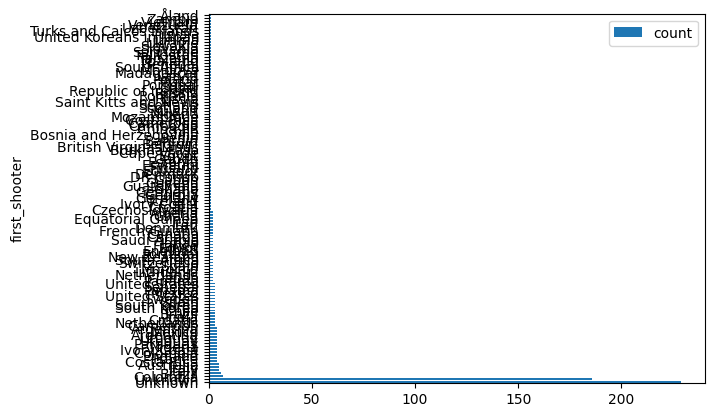

In [ ]:
# Plot countries by count of 'first_shooter'
shoot_grouped.set_index('first_shooter').plot(kind='barh', y='count')
# display plot
plt.show()

In [ ]:
# load the results csv and properly encode non english names
results = pd.read_csv('/content/results.csv', encoding='utf-8-sig')
# check table head
results.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False


In [ ]:
# check table columns and identify any null entries
results.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48366 entries, 0 to 48365
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   date        48366 non-null  object
 1   home_team   48366 non-null  object
 2   away_team   48366 non-null  object
 3   home_score  48366 non-null  int64 
 4   away_score  48366 non-null  int64 
 5   tournament  48366 non-null  object
 6   city        48366 non-null  object
 7   country     48366 non-null  object
 8   neutral     48366 non-null  bool  
dtypes: bool(1), int64(2), object(6)
memory usage: 3.0+ MB


In [ ]:
# change date column to datetime datatype
results['date'] = pd.to_datetime(results['date'])
# extract and create year column from date column
results['year'] = results['date'].dt.year
# extract and create day column from date column
results['day'] = results['date'].dt.dayofweek + 1

In [ ]:
# check changes
results.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year,day
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False,1872,6
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False,1873,6
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False,1874,6
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False,1875,6
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False,1876,6


In [ ]:
# check for null entries
results.isna().sum()

,0
date,0
home_team,0
away_team,0
home_score,0
away_score,0
tournament,0
city,0
country,0
neutral,0
year,0


In [ ]:
# check for duplicate entries
print(results.duplicated().sum())

0


In [ ]:
# check for outdated country names like Gold coast
results[results['country']== 'Gold Coast']

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year,day
3375,1950-05-28,Ghana,Nigeria,1,0,Friendly,Accra,Gold Coast,False,1950,7
3839,1953-10-11,Ghana,Nigeria,1,0,Friendly,Accra,Gold Coast,False,1953,7
3944,1954-06-01,Ghana,Sierra Leone,2,0,Friendly,Accra,Gold Coast,False,1954,2
4088,1955-05-28,Ghana,Nigeria,1,0,Friendly,Accra,Gold Coast,False,1955,6
4165,1955-10-30,Ghana,Nigeria,7,0,Friendly,Accra,Gold Coast,False,1955,7
4385,1956-12-16,Ghana,Sierra Leone,4,3,Friendly,Accra,Gold Coast,False,1956,7


In [ ]:
# check number of country entries for Ghana and Gold Coast before update
print(
    "Gold Coast: ", len(results[results['country']== 'Gold Coast']),
    "\nGhana: ", len(results[results['country']== 'Ghana'])
    )

Gold Coast:  6 
Ghana:  271


In [ ]:
# Update the country in the results dataframe
for index, row in fn.iterrows():
    former_name = row['former']
    current_name = row['current']
    results['country'] = results['country'].replace(former_name, current_name)


In [ ]:
# check number of current country entries for Ghana after update
len(results[results['country']== 'Ghana'])

277

In [ ]:
# extract and create decade column from date column
results['decade'] = (results['date'].dt.year // 10) * 10
# display table head
display(results.head(10))

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,year,day,decade
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False,1872,6,1870
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False,1873,6,1870
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False,1874,6,1870
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False,1875,6,1870
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False,1876,6,1870
5,1876-03-25,Scotland,Wales,4,0,Friendly,Glasgow,Scotland,False,1876,6,1870
6,1877-03-03,England,Scotland,1,3,Friendly,London,England,False,1877,6,1870
7,1877-03-05,Wales,Scotland,0,2,Friendly,Wrexham,Wales,False,1877,1,1870
8,1878-03-02,Scotland,England,7,2,Friendly,Glasgow,Scotland,False,1878,6,1870
9,1878-03-23,Scotland,Wales,9,0,Friendly,Glasgow,Scotland,False,1878,6,1870


In [ ]:
shoot.info()
gs.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 650 entries, 0 to 649
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   date           650 non-null    object
 1   home_team      650 non-null    object
 2   away_team      650 non-null    object
 3   winner         650 non-null    object
 4   first_shooter  650 non-null    object
 5   winning_team   650 non-null    object
dtypes: object(6)
memory usage: 30.6+ KB
<class 'pandas.core.frame.DataFrame'>
Index: 44181 entries, 0 to 44446
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   date         44181 non-null  datetime64[ns]
 1   home_team    44181 non-null  object        
 2   away_team    44181 non-null  object        
 3   team         44181 non-null  object        
 4   scorer       44181 non-null  object        
 5   minute       44181 non-null  float64       
 6   own_goal  

In [ ]:
fn.info()
results.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34 entries, 0 to 33
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   current     34 non-null     object        
 1   former      34 non-null     object        
 2   start_date  34 non-null     datetime64[ns]
 3   end_date    34 non-null     datetime64[ns]
dtypes: datetime64[ns](2), object(2)
memory usage: 1.2+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48366 entries, 0 to 48365
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        48366 non-null  datetime64[ns]
 1   home_team   48366 non-null  object        
 2   away_team   48366 non-null  object        
 3   home_score  48366 non-null  int64         
 4   away_score  48366 non-null  int64         
 5   tournament  48366 non-null  object        
 6   city        48366 non-null  object        
 7   count

In [ ]:
# save the cleaned dataframes to csv making sure to properly encode them
shoot.to_csv('/content/shootouts_cleaned.csv', index=False, encoding='utf-8-sig')
gs.to_csv('/content/goalscorers_cleaned.csv', index=False, encoding='utf-8-sig')
fn.to_csv('/content/former_names_cleaned.csv', index=False, encoding='utf-8-sig')
results.to_csv('/content/results_cleaned.csv', index=False, encoding= 'utf-8-sig')